In [146]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings 
import joblib

In [147]:
warnings.filterwarnings('ignore')

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [148]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [149]:
from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.svm import SVC

from xgboost import XGBClassifier

In [150]:
data = pd.read_csv("Data/heart.csv")
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [151]:
df = data.copy()
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [152]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [153]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 918
Columns : 12


In [154]:
df.columns.tolist()

['Age',
 'Sex',
 'ChestPainType',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'RestingECG',
 'MaxHR',
 'ExerciseAngina',
 'Oldpeak',
 'ST_Slope',
 'HeartDisease']

In [155]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [157]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [158]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [159]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Text(0.5, 1.0, 'Missing Values Heatmap')

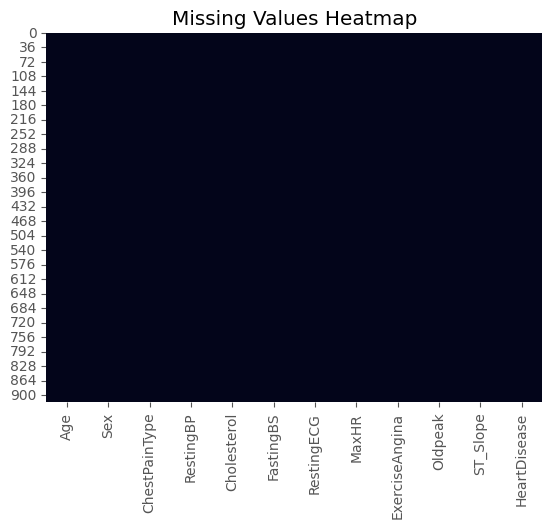

In [160]:
sns.heatmap(df.isnull(), cbar = False)
plt.title("Missing Values Heatmap")

In [161]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [162]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

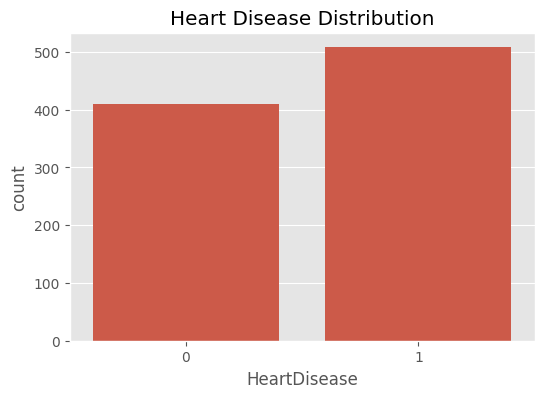

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


In [163]:
plt.figure(figsize=(6,4))

sns.countplot(x="HeartDisease", data=df)

plt.title("Heart Disease Distribution")
plt.show()

print(df["HeartDisease"].value_counts(normalize=True))

In [164]:
num_cols = df.select_dtypes(include=np.number).columns

num_cols.tolist()

['Age',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'MaxHR',
 'Oldpeak',
 'HeartDisease']

In [165]:
cat_cols = df.select_dtypes(exclude=np.number).columns

cat_cols.tolist()

['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

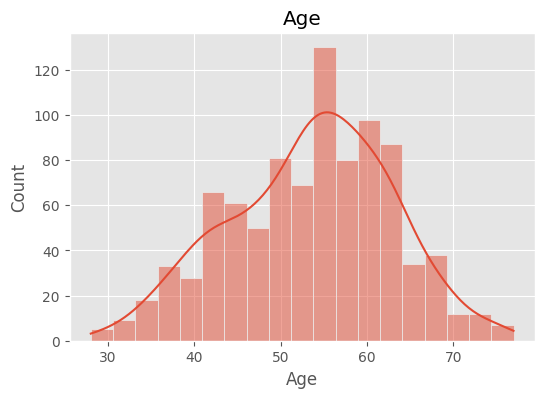

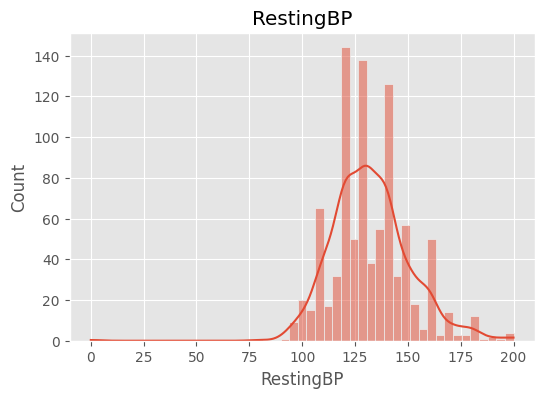

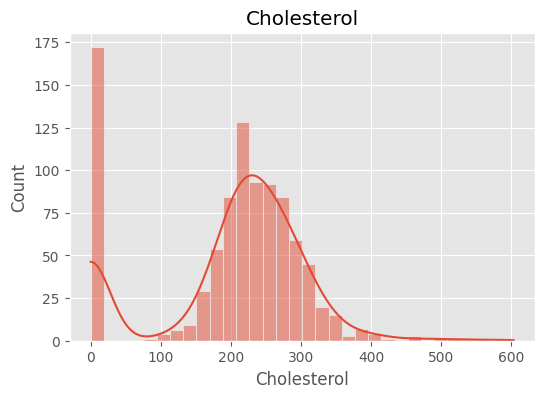

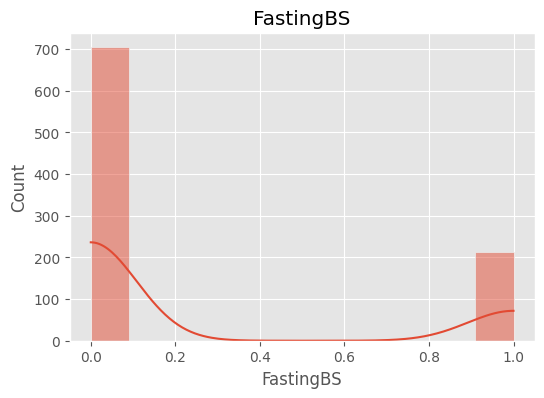

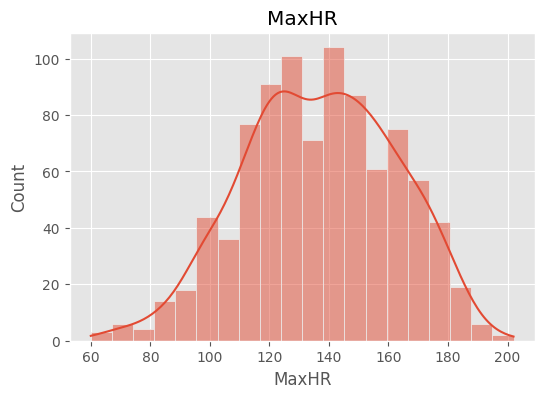

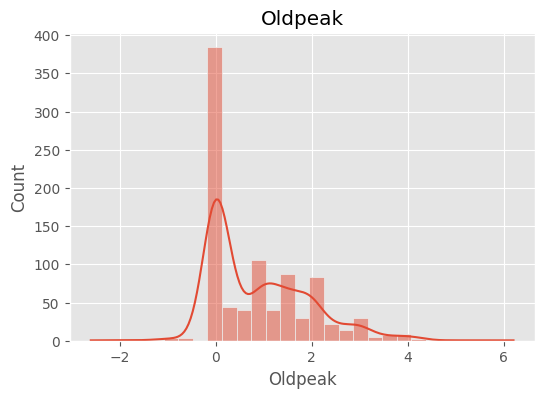

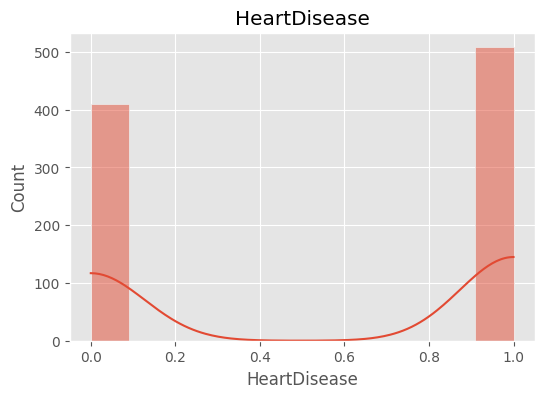

In [166]:
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

    print()

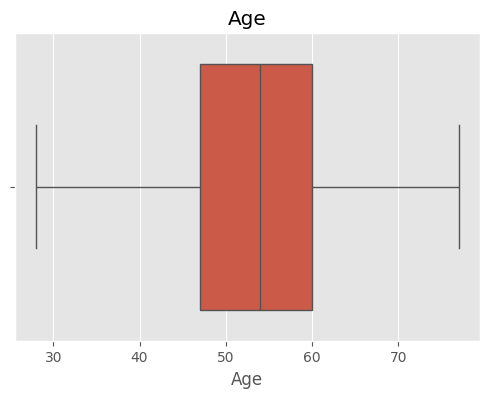

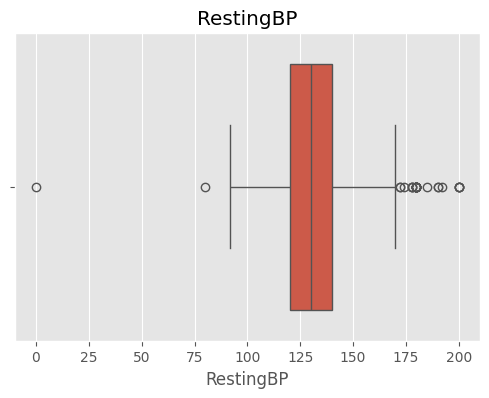

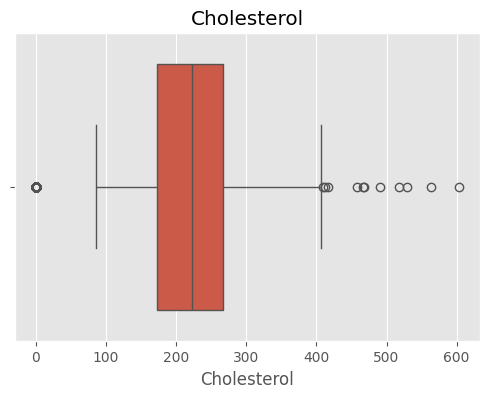

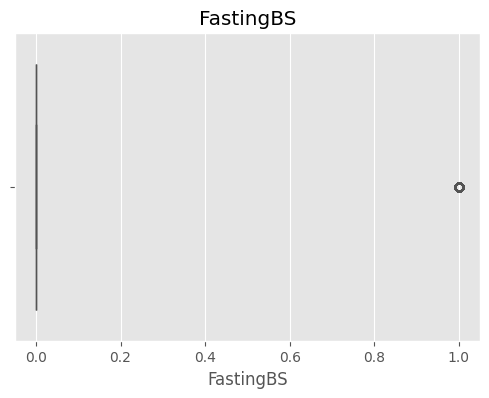

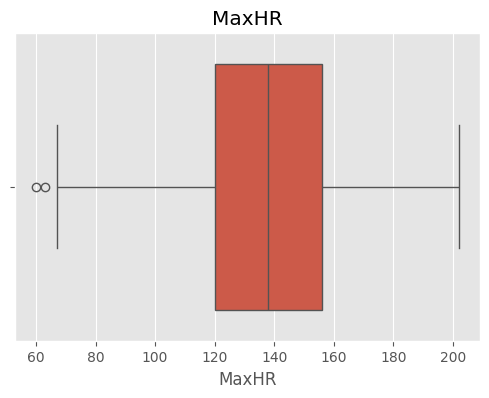

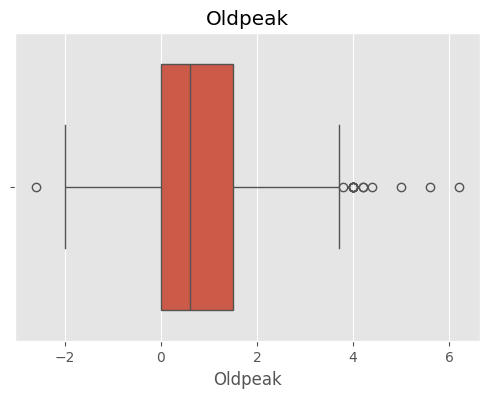

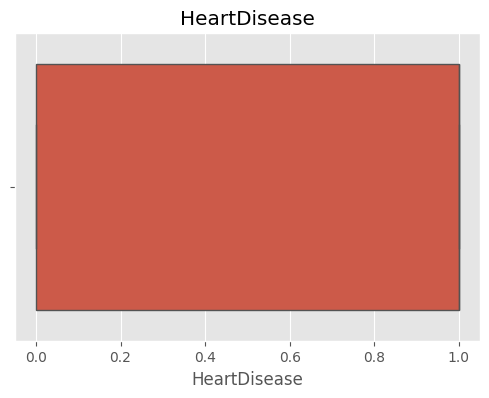

In [167]:
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

    print()

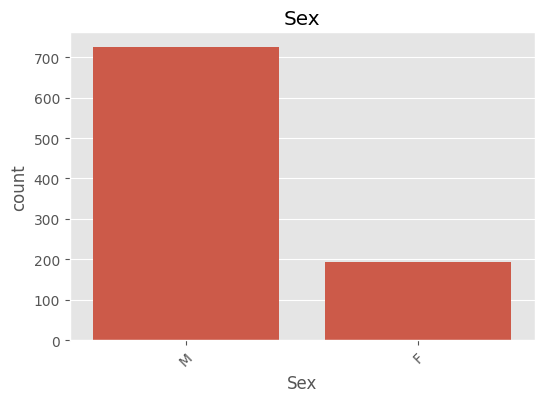

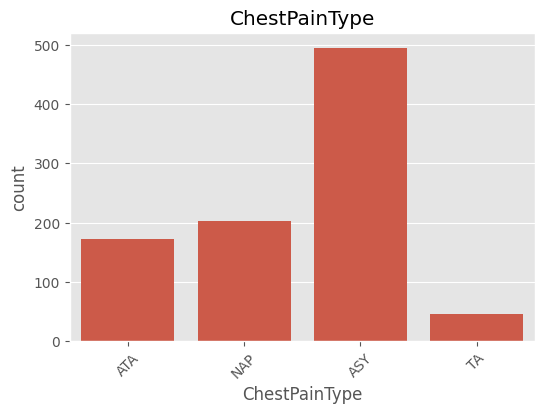

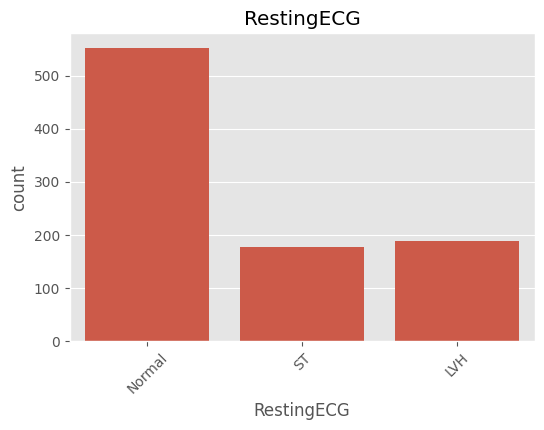

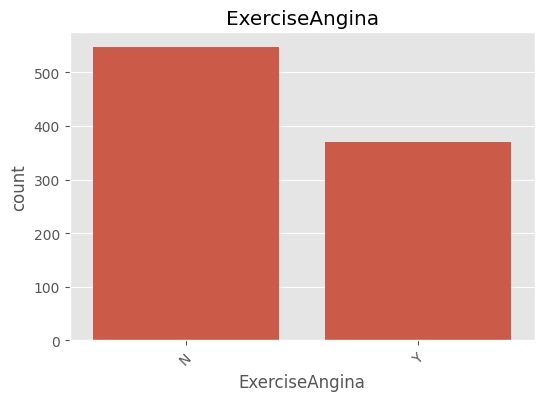

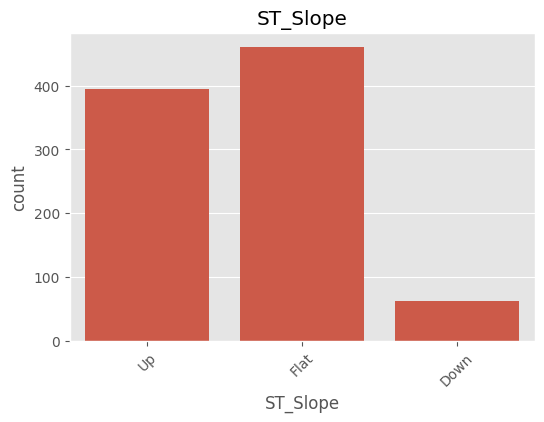

In [168]:
for col in cat_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(x=col, data=df)

    plt.title(col)

    plt.xticks(rotation=45)

    plt.show()

    print()

In [169]:
corr = df.corr(numeric_only=True)

print(corr)

                   Age  RestingBP  Cholesterol  FastingBS     MaxHR   Oldpeak  \
Age           1.000000   0.254399    -0.095282   0.198039 -0.382045  0.258612   
RestingBP     0.254399   1.000000     0.100893   0.070193 -0.112135  0.164803   
Cholesterol  -0.095282   0.100893     1.000000  -0.260974  0.235792  0.050148   
FastingBS     0.198039   0.070193    -0.260974   1.000000 -0.131438  0.052698   
MaxHR        -0.382045  -0.112135     0.235792  -0.131438  1.000000 -0.160691   
Oldpeak       0.258612   0.164803     0.050148   0.052698 -0.160691  1.000000   
HeartDisease  0.282039   0.107589    -0.232741   0.267291 -0.400421  0.403951   

              HeartDisease  
Age               0.282039  
RestingBP         0.107589  
Cholesterol      -0.232741  
FastingBS         0.267291  
MaxHR            -0.400421  
Oldpeak           0.403951  
HeartDisease      1.000000  


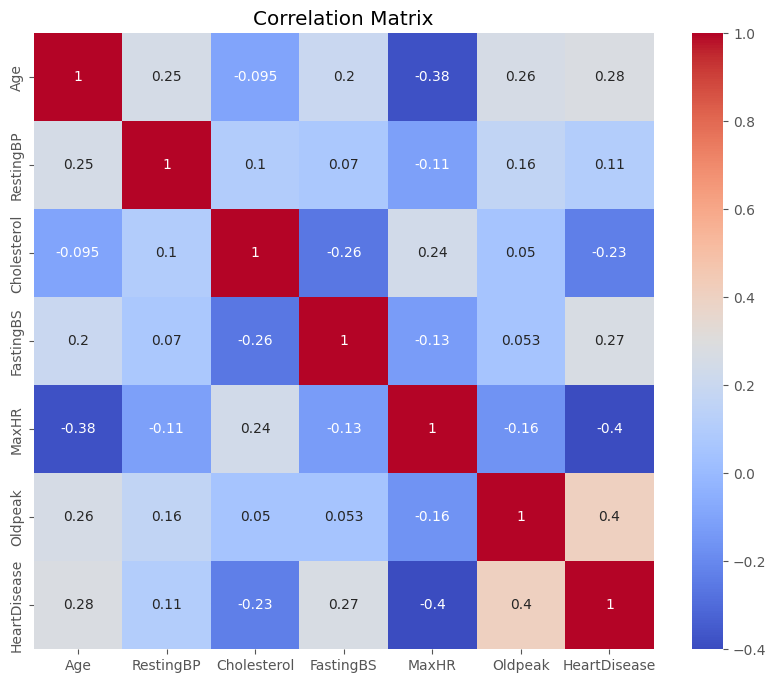

In [170]:
plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

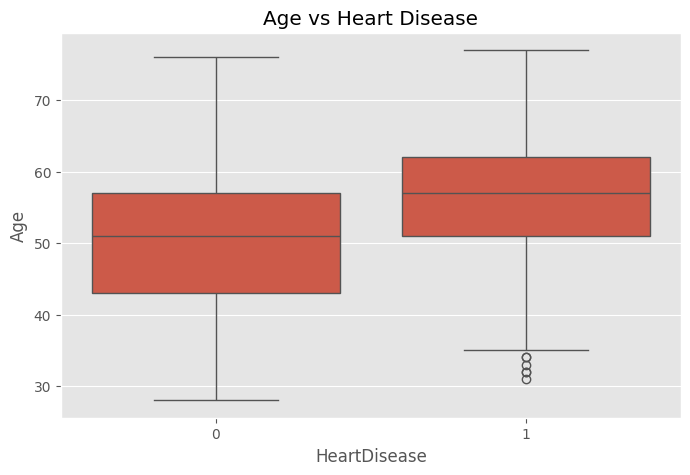

In [171]:
plt.figure(figsize=(8,5))

sns.boxplot(x="HeartDisease", y="Age", data=df)

plt.title("Age vs Heart Disease")

plt.show()

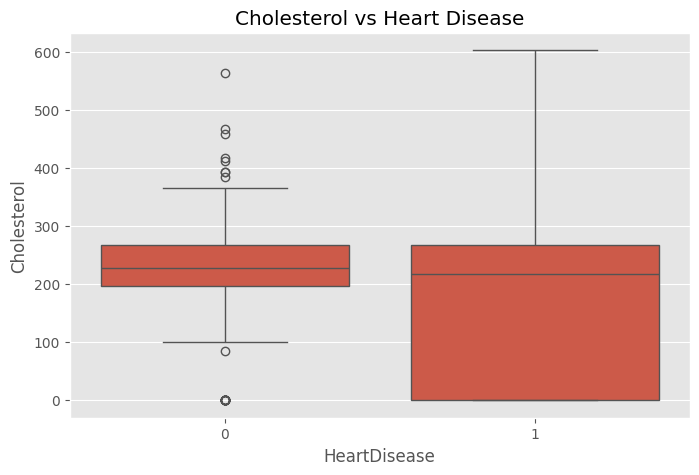

In [172]:
plt.figure(figsize=(8,5))

sns.boxplot(x="HeartDisease", y="Cholesterol", data=df)

plt.title("Cholesterol vs Heart Disease")

plt.show()

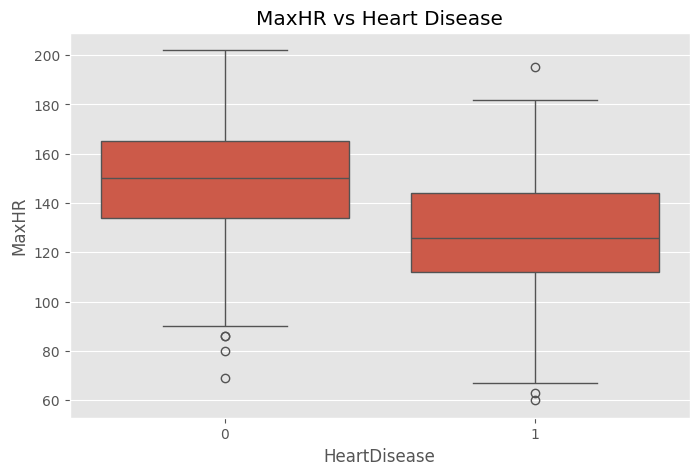

In [173]:
plt.figure(figsize=(8,5))

sns.boxplot(x="HeartDisease", y="MaxHR", data=df)

plt.title("MaxHR vs Heart Disease")

plt.show()

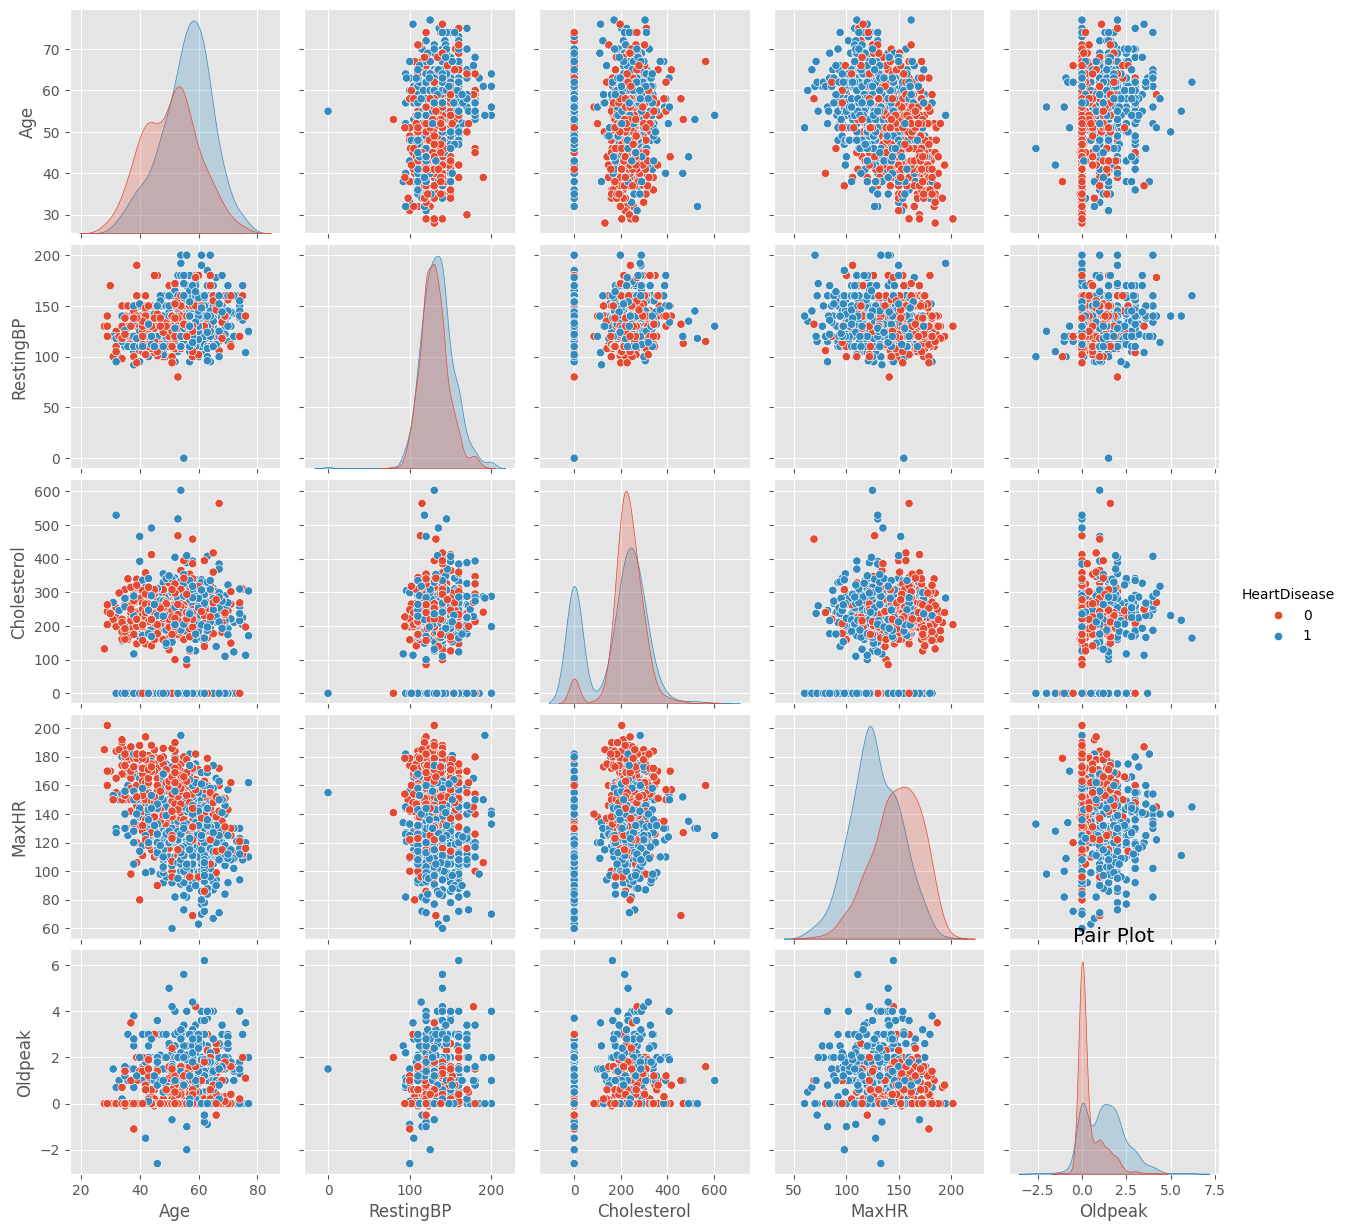

In [174]:
sns.pairplot(df[["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak","HeartDisease"]],
            hue="HeartDisease")

plt.title("Pair Plot")

plt.show()

In [175]:
percentage = (df["HeartDisease"].value_counts(normalize=True) * 100)

percentage

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64

In [176]:
corr_target = corr["HeartDisease"].sort_values(ascending=False)

corr_target

HeartDisease    1.000000
Oldpeak         0.403951
Age             0.282039
FastingBS       0.267291
RestingBP       0.107589
Cholesterol    -0.232741
MaxHR          -0.400421
Name: HeartDisease, dtype: float64

In [177]:
Cholesterol_mean = df.loc[df["Cholesterol"] != 0, "Cholesterol"].mean()
Cholesterol_mean

np.float64(244.6353887399464)

In [178]:
df["Cholesterol"] = df["Cholesterol"].replace(0, Cholesterol_mean)
df["Cholesterol"] = df["Cholesterol"].round(2)
df["Cholesterol"].value_counts()

Cholesterol
244.64    172
254.00     11
220.00     10
223.00     10
204.00      9
         ... 
353.00      1
278.00      1
157.00      1
176.00      1
131.00      1
Name: count, Length: 222, dtype: int64

In [179]:
restingbp_mean = df.loc[df["RestingBP"] != 0, "RestingBP"].mean()
restingbp_mean

np.float64(132.54089422028352)

In [180]:
df["RestingBP"] = df["RestingBP"].replace(0, restingbp_mean)
df["RestingBP"] = df["RestingBP"].round(2)
df["RestingBP"].value_counts()

RestingBP
120.0    132
130.0    118
140.0    107
110.0     58
150.0     55
        ... 
101.0      1
117.0      1
192.0      1
129.0      1
164.0      1
Name: count, Length: 67, dtype: int64

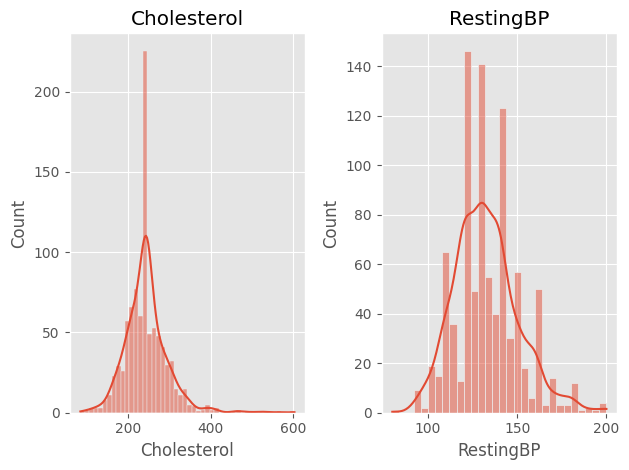

In [181]:
plt.subplot(1, 2, 1)
sns.histplot(data = df, x = "Cholesterol", kde = True)
plt.title(f"Cholesterol")

plt.subplot(1, 2, 2)
sns.histplot(data = df, x = "RestingBP", kde = True)
plt.title(f"RestingBP")

plt.tight_layout()

In [182]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [183]:
df[num_cols].head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
0,40,140.0,289.0,0,172,0.0,0
1,49,160.0,180.0,0,156,1.0,1
2,37,130.0,283.0,0,98,0.0,0
3,48,138.0,214.0,0,108,1.5,1
4,54,150.0,195.0,0,122,0.0,0


In [184]:
df[cat_cols].head()

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up


<Axes: xlabel='Age', ylabel='Cholesterol'>

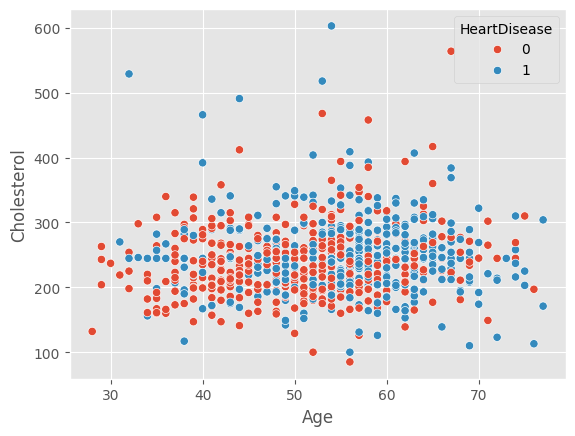

In [185]:
sns.scatterplot(data = df, y = "Cholesterol", x = "Age", hue = "HeartDisease")

<Axes: xlabel='Age', ylabel='RestingBP'>

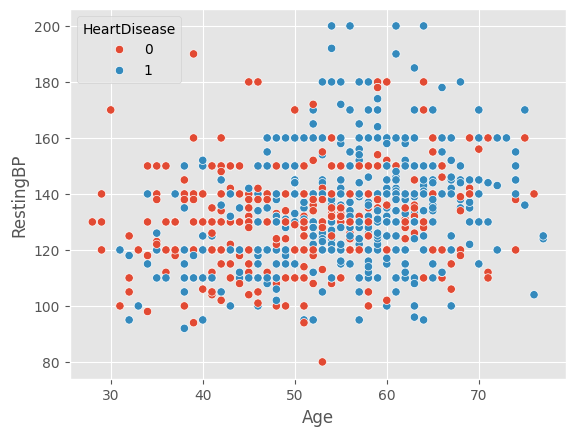

In [186]:
sns.scatterplot(data = df, y = "RestingBP", x = "Age", hue = "HeartDisease")

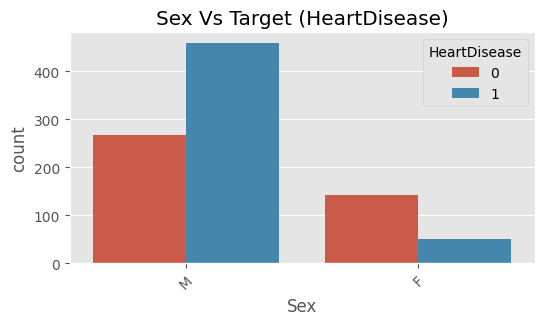

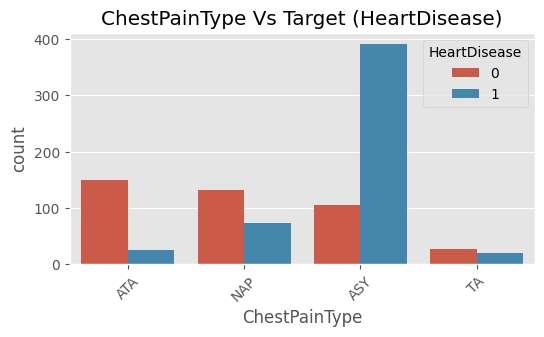

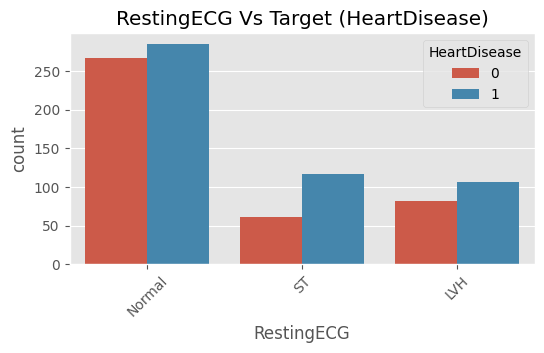

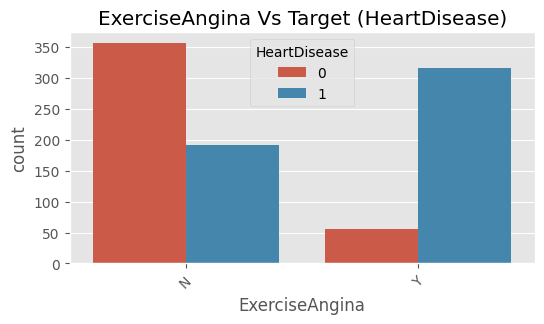

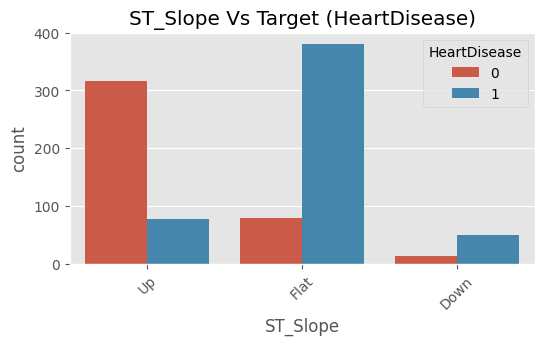

In [187]:
for col in cat_cols: 
    plt.figure(figsize=(6, 3))
    sns.countplot(x = col, hue = "HeartDisease", data = df) 
    plt.title(f"{col} Vs Target (HeartDisease)")
    plt.xticks(rotation = 45)
    plt.show()
    print()

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

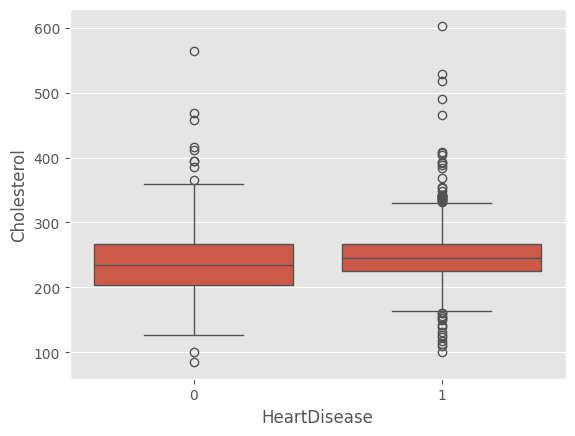

In [188]:
sns.boxplot(x='HeartDisease', y='Cholesterol', data=df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

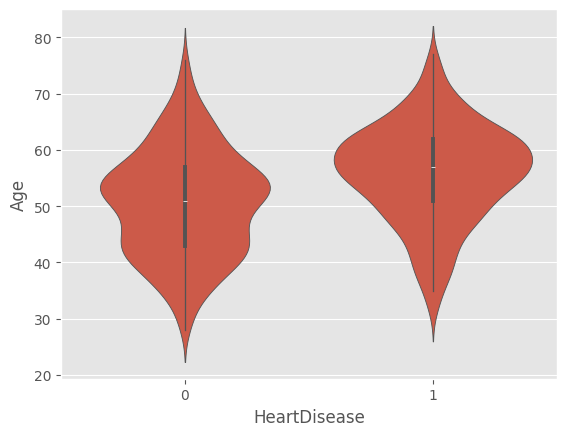

In [189]:
sns.violinplot(x='HeartDisease', y='Age', data=df)

<Axes: xlabel='HeartDisease', ylabel='RestingBP'>

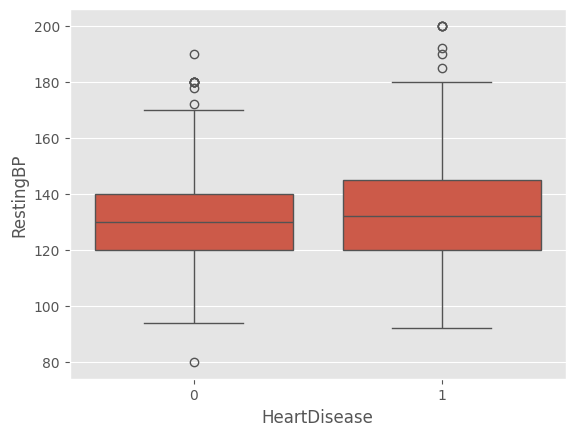

In [190]:
sns.boxplot(x='HeartDisease', y='RestingBP', data=df)

In [191]:
corr = df.corr(numeric_only=True)
corr

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.263081,0.053378,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.263081,1.000000,0.083074,0.067812,-0.109662,0.174220,0.117938
Cholesterol,0.053378,0.083074,1.000000,0.043019,-0.017248,0.053028,0.094082
FastingBS,0.198039,0.067812,0.043019,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.109662,-0.017248,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.174220,0.053028,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.117938,0.094082,0.267291,-0.400421,0.403951,1.000000


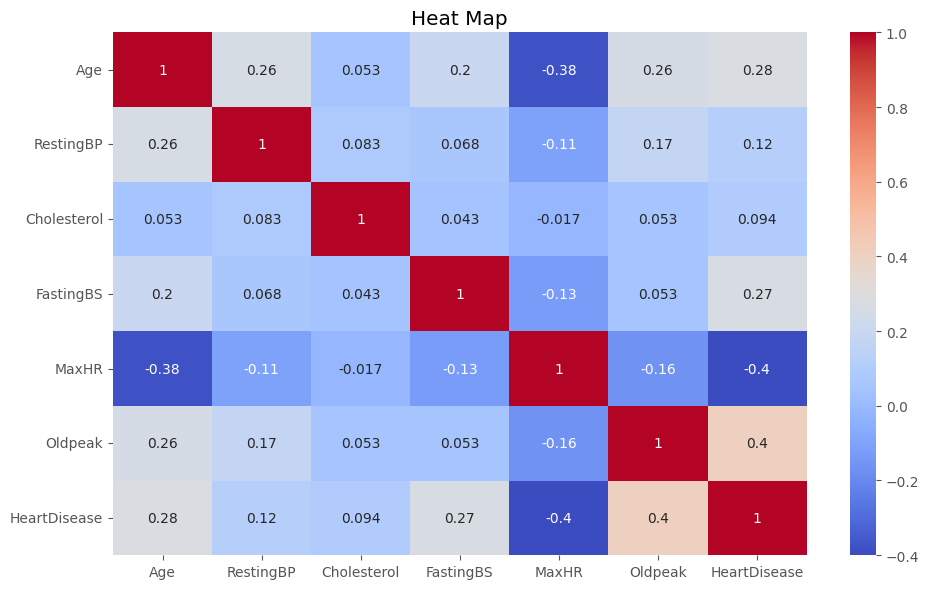

In [192]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Heat Map")
plt.tight_layout()
plt.show()

In [193]:
print(corr["HeartDisease"].sort_values(ascending=False))

HeartDisease    1.000000
Oldpeak         0.403951
Age             0.282039
FastingBS       0.267291
RestingBP       0.117938
Cholesterol     0.094082
MaxHR          -0.400421
Name: HeartDisease, dtype: float64


In [194]:
print("Key Findings")

print("- Dataset contains 918 records.")
print("- No missing values found.")
print("- No duplicate values found.")
print("- HeartDisease target is fairly balanced.")
print("- Oldpeak has strong positive correlation.")
print("- MaxHR has negative correlation.")
print("- Age contributes significantly.")
print("- Exercise Angina is a strong indicator.")

Key Findings
- Dataset contains 918 records.
- No missing values found.
- No duplicate values found.
- HeartDisease target is fairly balanced.
- Oldpeak has strong positive correlation.
- MaxHR has negative correlation.
- Age contributes significantly.
- Exercise Angina is a strong indicator.


In [195]:
df.to_csv("Data/heart_clean.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [196]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [197]:
X = df.drop("HeartDisease", axis=1)

y = df["HeartDisease"]

print(X.shape)
print(y.shape)

(918, 11)
(918,)


In [198]:
num_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]

num_cols

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

In [199]:
cat_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

cat_cols

['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

In [200]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(734, 11)
(184, 11)


In [201]:
preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), num_cols),
                ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [202]:
preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [203]:
X_train_processed = preprocessor.transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(734, 20)
(184, 20)


In [204]:
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['num__Age', 'num__RestingBP', 'num__Cholesterol', 'num__FastingBS',
       'num__MaxHR', 'num__Oldpeak', 'cat__Sex_F', 'cat__Sex_M',
       'cat__ChestPainType_ASY', 'cat__ChestPainType_ATA',
       'cat__ChestPainType_NAP', 'cat__ChestPainType_TA',
       'cat__RestingECG_LVH', 'cat__RestingECG_Normal',
       'cat__RestingECG_ST', 'cat__ExerciseAngina_N',
       'cat__ExerciseAngina_Y', 'cat__ST_Slope_Down',
       'cat__ST_Slope_Flat', 'cat__ST_Slope_Up'], dtype=object)

In [205]:
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)

X_train_df.head()

,num__Age,num__RestingBP,num__Cholesterol,num__FastingBS,num__MaxHR,num__Oldpeak,cat__Sex_F,cat__Sex_M,cat__ChestPainType_ASY,cat__ChestPainType_ATA,cat__ChestPainType_NAP,cat__ChestPainType_TA,cat__RestingECG_LVH,cat__RestingECG_Normal,cat__RestingECG_ST,cat__ExerciseAngina_N,cat__ExerciseAngina_Y,cat__ST_Slope_Down,cat__ST_Slope_Flat,cat__ST_Slope_Up
0,0.970012,0.339016,-0.539951,1.835497,-0.324520,0.317046,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,0.122028,-1.266031,-0.595382,1.835497,1.689837,-0.440356,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,0.546020,-0.159102,1.695768,1.835497,-0.247045,0.601071,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,-0.725956,1.501291,-0.029246,-0.544812,-0.479470,-0.819056,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-0.407962,0.671094,-0.029246,1.835497,0.101594,-0.156330,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [206]:
X_train_df.isnull().sum().sum()

np.int64(0)

In [207]:
print("Total Engineered Features:", len(feature_names))

Total Engineered Features: 20


In [209]:
joblib.dump(preprocessor, "models/preprocessor.pkl")

print("Preprocessor Saved Successfully")

Preprocessor Saved Successfully


In [210]:
joblib.dump(X_train, "models/X_train.pkl")

joblib.dump(X_test, "models/X_test.pkl")

joblib.dump(y_train, "models/y_train.pkl")

joblib.dump(y_test, "models/y_test.pkl")

print("Datasets Saved Successfully")

Datasets Saved Successfully


In [211]:
print("Feature Engineering Completed")

print("="*50)

print("Numerical Features :", len(num_cols))
print("Categorical Features :", len(cat_cols))

print("Original Features :", X.shape[1])

print("Engineered Features :", len(feature_names))

print("="*50)

Feature Engineering Completed
Numerical Features : 6
Categorical Features : 5
Original Features : 11
Engineered Features : 20


In [212]:
processed_df = pd.DataFrame(preprocessor.transform(X), columns=feature_names)

processed_df["HeartDisease"] = y.values

processed_df.to_csv("Data/heart_processed.csv",index=False)

print("Processed Dataset Saved")

Processed Dataset Saved


In [213]:
X_train.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
485,63,M,ATA,139.0,217.00,1,ST,128,Y,1.2,Flat
486,55,M,ATA,110.0,214.00,1,ST,180,N,0.4,Up
117,59,F,ASY,130.0,338.00,1,ST,130,Y,1.5,Flat
361,47,M,ASY,160.0,244.64,0,Normal,124,Y,0.0,Flat
296,50,M,ASY,145.0,244.64,1,Normal,139,Y,0.7,Flat


In [214]:
y_train.head()

485    1
486    0
117    1
361    1
296    1
Name: HeartDisease, dtype: int64

In [215]:
X_test.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
356,46,M,ASY,115.0,244.64,0,Normal,113,Y,1.5,Flat
763,58,M,NAP,132.0,224.00,0,LVH,173,N,3.2,Up
817,60,M,ASY,125.0,258.00,0,LVH,141,Y,2.8,Flat
735,49,M,NAP,120.0,188.00,0,Normal,139,N,2.0,Flat
892,39,F,NAP,138.0,220.00,0,Normal,152,N,0.0,Flat


In [216]:
y_test.head()

356    1
763    1
817    1
735    1
892    0
Name: HeartDisease, dtype: int64

In [217]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [218]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "SVM": SVC(probability=True),

    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss")
}

In [219]:
results = []

for name, model in models.items():

    pipe = Pipeline([("preprocessor", preprocessor),
                    ("model", model)
                    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    prob = pipe.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, pred)

    precision = precision_score(y_test, pred)

    recall = recall_score(y_test, pred)

    f1 = f1_score(y_test, pred)

    roc_auc = roc_auc_score(y_test, prob)

    results.append([name, acc, precision, recall, f1, roc_auc])

results_df = pd.DataFrame(results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
)

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
4,Random Forest,0.891304,0.894231,0.911765,0.902913,0.930954
0,Logistic Regression,0.885870,0.885714,0.911765,0.898551,0.933405
5,Gradient Boosting,0.880435,0.892157,0.892157,0.892157,0.913797
1,Naive Bayes,0.869565,0.890000,0.872549,0.881188,0.907221
6,SVM,0.869565,0.861111,0.911765,0.885714,0.942492
2,KNN,0.864130,0.873786,0.882353,0.878049,0.926231
7,XGBoost,0.831522,0.865979,0.823529,0.844221,0.904950
3,Decision Tree,0.782609,0.816327,0.784314,0.800000,0.782401


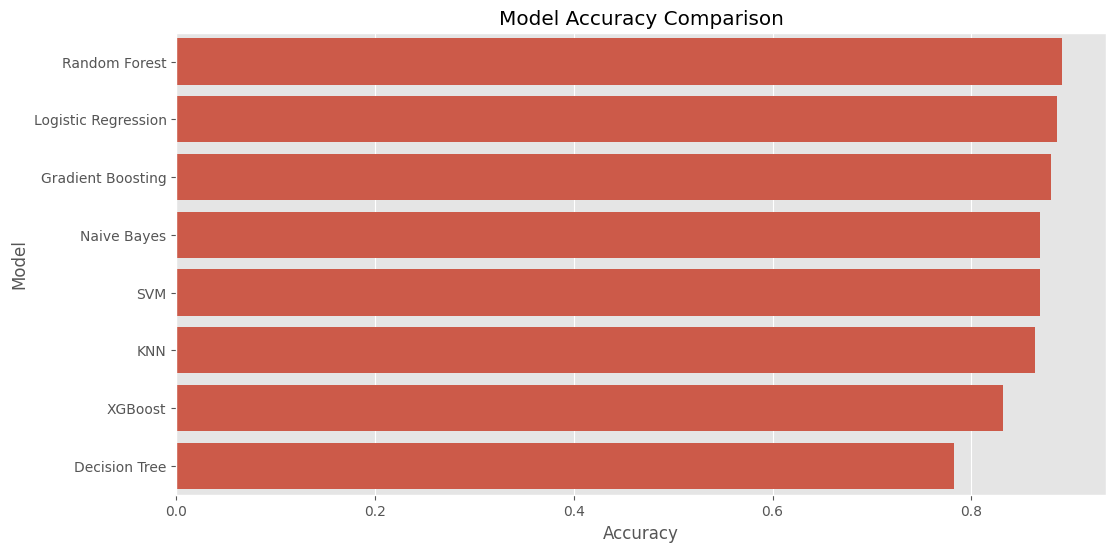

In [220]:
plt.figure(figsize=(12,6))

sns.barplot(x="Accuracy", y="Model",
    data=results_df.sort_values("Accuracy", ascending=False)
)

plt.title("Model Accuracy Comparison")

plt.show()

In [221]:
cv_results = []

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor),
                    ("model", model)
                    ])

    score = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append([name, score.mean()])

cv_df = pd.DataFrame(cv_results, columns=["Model", "CV Accuracy"])

cv_df.sort_values("CV Accuracy", ascending=False)

,Model,CV Accuracy
6,SVM,0.862324
4,Random Forest,0.852847
0,Logistic Regression,0.848719
1,Naive Bayes,0.848719
2,KNN,0.844656
7,XGBoost,0.841925
5,Gradient Boosting,0.839195
3,Decision Tree,0.805163


In [222]:
xgb_pipe = Pipeline([("preprocessor", preprocessor),
                     ("model", XGBClassifier(random_state=42, eval_metric="logloss"))
                    ])

In [223]:
param_grid = {"model__n_estimators": [100, 300, 500],
              "model__max_depth": [3, 4, 5],
              "model__learning_rate": [0.01, 0.05, 0.1]
             }

In [224]:
grid = GridSearchCV(estimator=xgb_pipe,
                    param_grid=param_grid,
                    scoring="accuracy",
                    cv=5,
                    n_jobs=-1,
                    verbose=1
                   )

grid.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [100, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

In [225]:
print("Best Parameters:")

grid.best_params_

Best Parameters:


{'model__learning_rate': 0.1,
 'model__max_depth': 3,
 'model__n_estimators': 300}

In [226]:
best_model = grid.best_estimator_

best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [227]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:,1]

In [228]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score( y_test, y_prob))

Accuracy: 0.8641304347826086
Precision: 0.8811881188118812
Recall: 0.8725490196078431
F1 Score: 0.8768472906403941
ROC AUC: 0.9158297465327594


In [229]:
print("Classification Report \n", classification_report(y_test, y_pred))

Classification Report 
               precision    recall  f1-score   support

           0       0.84      0.85      0.85        82
           1       0.88      0.87      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [230]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix \n", cm)

Confusion Matrix 
 [[70 12]
 [13 89]]


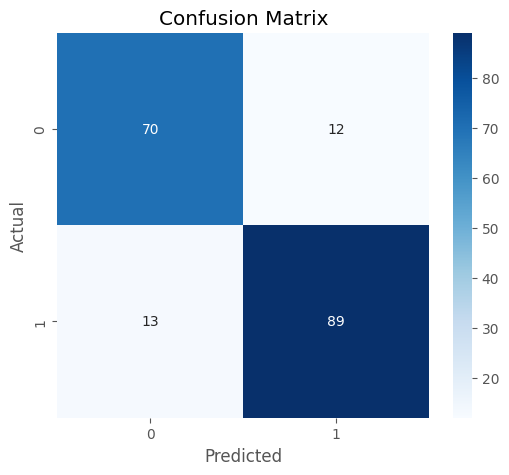

In [231]:
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

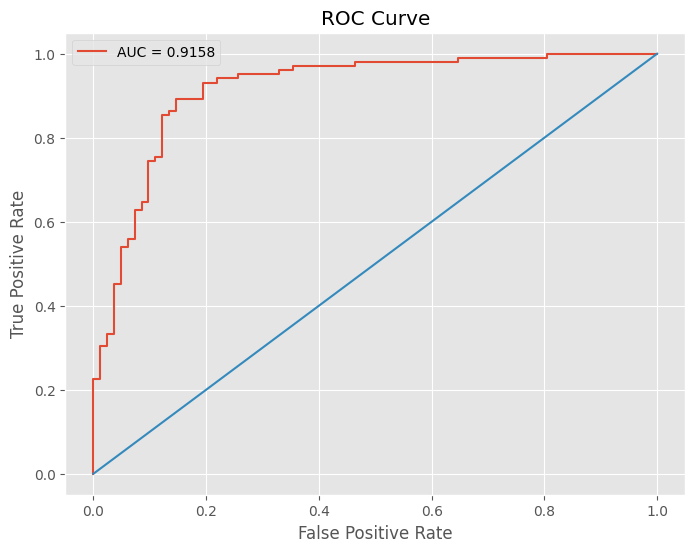

In [232]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test,y_prob):.4f}")

plt.plot(
    [0,1],
    [0,1]
)

plt.legend()

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [233]:
feature_names = preprocessor.get_feature_names_out()

importance = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({"Feature": feature_names,
                              "Importance": importance
                             })

importance_df = importance_df.sort_values("Importance", ascending=False)

importance_df.head(20)

,Feature,Importance
19,cat__ST_Slope_Up,0.639427
8,cat__ChestPainType_ASY,0.072726
15,cat__ExerciseAngina_N,0.045189
3,num__FastingBS,0.032803
6,cat__Sex_F,0.031637
5,num__Oldpeak,0.024489
14,cat__RestingECG_ST,0.018001
12,cat__RestingECG_LVH,0.017932
4,num__MaxHR,0.016884
2,num__Cholesterol,0.014561


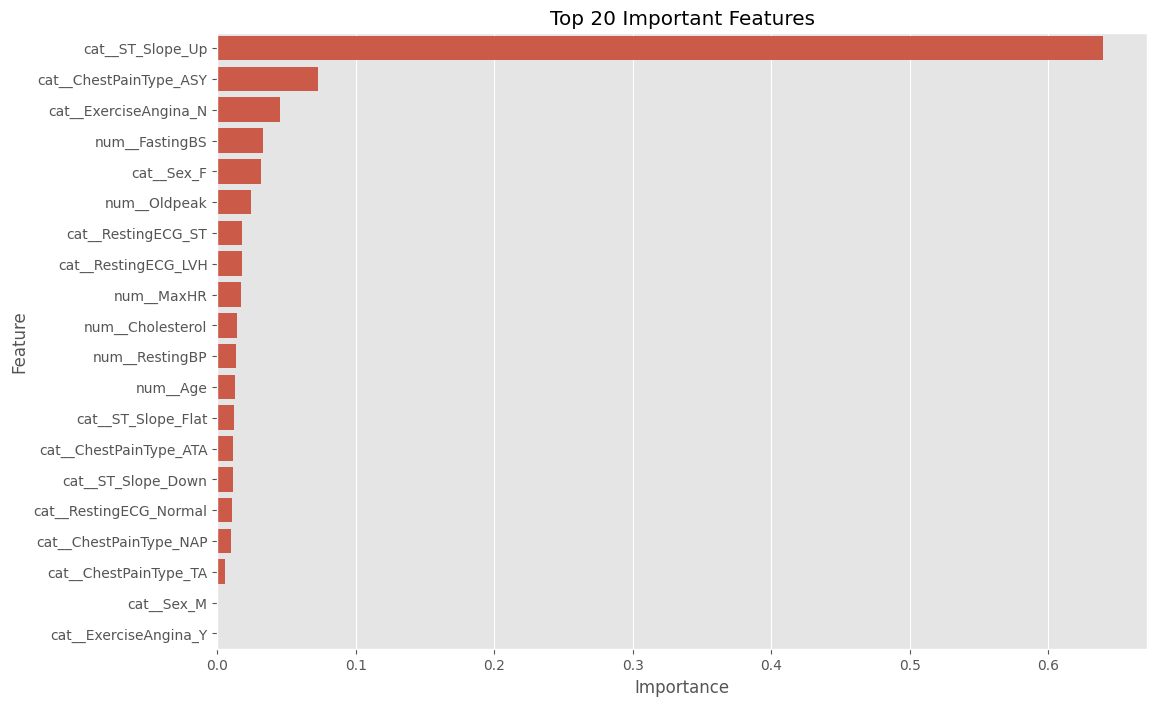

In [234]:
plt.figure(figsize=(12,8))

sns.barplot(x="Importance", y="Feature", data=importance_df.head(20))

plt.title("Top 20 Important Features")

plt.show()

In [235]:
joblib.dump(best_model, "models/heart_best_model.pkl")

print("Best Model Saved Successfully")

Best Model Saved Successfully


In [236]:
loaded_model = joblib.load( "models/heart_best_model.pkl")

loaded_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co